Обработка изображений...
  peppers.tiff
  mandrill.tiff
  splash.tiff
  house.tiff
  female1.tiff
  female2.tiff
  female3.tiff

СРАВНЕНИЕ ОРИГИНАЛЬНЫХ ИЗОБРАЖЕНИЙ (NHD)
            peppers.timandrill.tsplash.tifhouse.tifffemale1.tifemale2.tifemale3.ti
  peppers.ti    0.0000    0.4492    0.5078    0.5254    0.5117    0.4434    0.4531
  mandrill.t    0.4492    0.0000    0.4688    0.5605    0.5352    0.5762    0.5078
  splash.tif    0.5078    0.4688    0.0000    0.6699    0.4453    0.6348    0.5078
  house.tiff    0.5254    0.5605    0.6699    0.0000    0.5020    0.3438    0.5879
  female1.ti    0.5117    0.5352    0.4453    0.5020    0.0000    0.4551    0.4102
  female2.ti    0.4434    0.5762    0.6348    0.3438    0.4551    0.0000    0.4980
  female3.ti    0.4531    0.5078    0.5078    0.5879    0.4102    0.4980    0.0000

СРАВНЕНИЕ ЗАШУМЛЁННЫХ ИЗОБРАЖЕНИЙ (NHD)
            peppers.timandrill.tsplash.tifhouse.tifffemale1.tifemale2.tifemale3.ti
  peppers.ti    0.0000    0.4375    0.5117

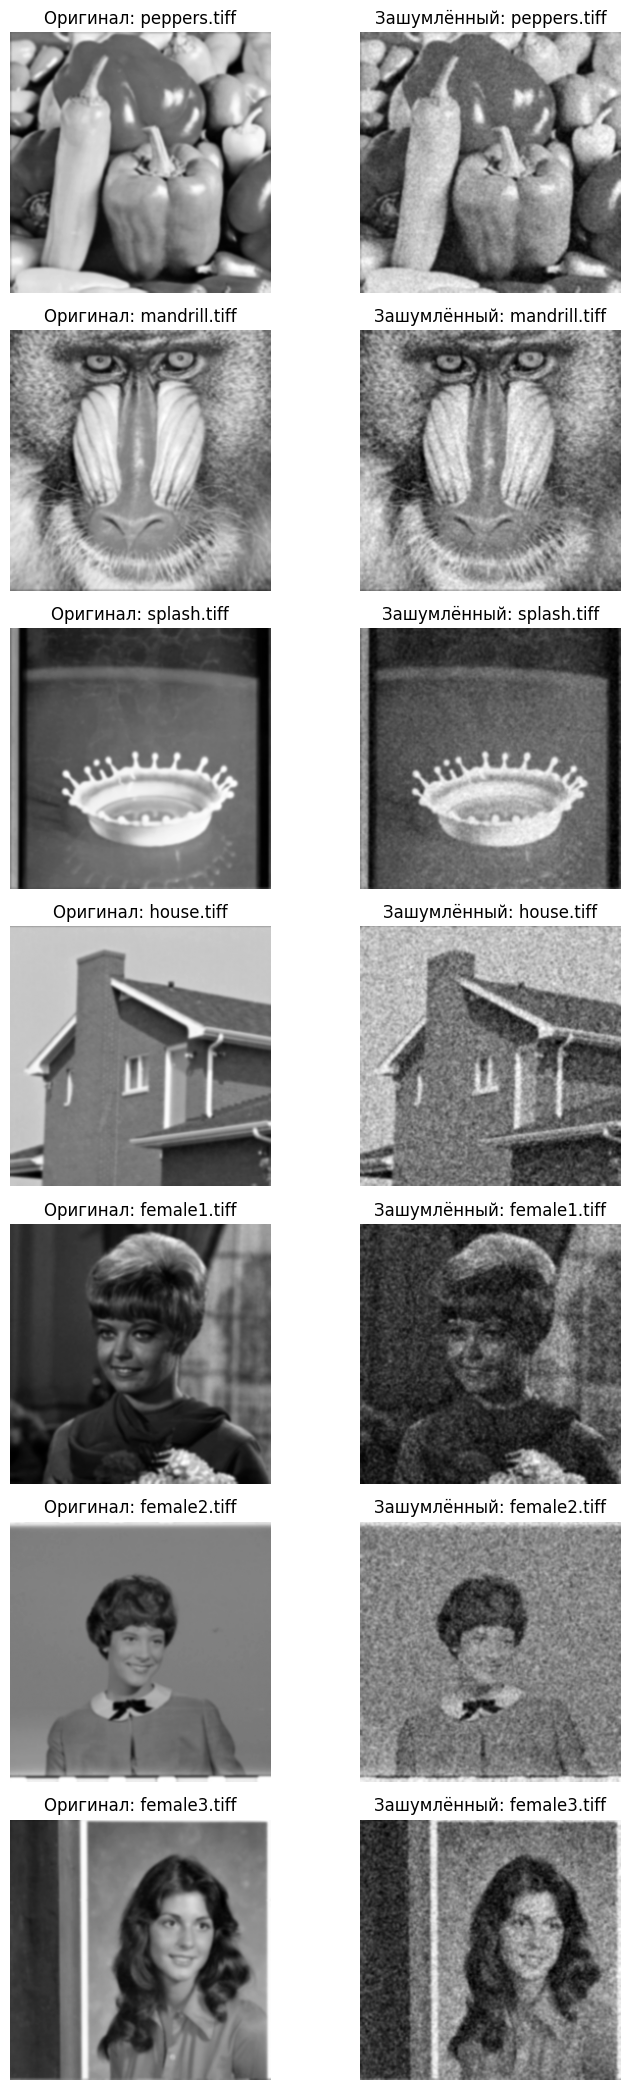

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import math
import itertools
from typing import List, Tuple

# --------------------------------------------------------------
#  Вспомогательные функции для WHT и моментов Кравчука
# --------------------------------------------------------------

def preprocess(img_color, target_size=(256, 256)):
    """Перевод в оттенки серого, ресайз и размытие по Гауссу."""
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)


def split_blocks(img, block_size):
    """Разбивает изображение на блоки block_size x block_size."""
    h, w = img.shape
    # Изображение должно нацело делиться на размер блока
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    # Переформируем массив в (число_блоков, block_size, block_size)
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks


def get_zigzag_indices(n):
    """Возвращает порядок обхода zigzag для квадратной матрицы n x n."""
    indices = []
    for s in range(2 * n - 1):
        if s % 2 == 0:
            for i in range(min(s, n - 1), max(-1, s - n), -1):
                j = s - i
                indices.append((i, j))
        else:
            for j in range(min(s, n - 1), max(-1, s - n), -1):
                i = s - j
                indices.append((i, j))
    return indices


def wht2d(block, H):
    """Двумерное преобразование Уолша–Адамара через матричное умножение."""
    return H @ block @ H.T


def extract_wht_features(blocks, num_coeffs=128):
    """Для каждого блока вычисляем первые num_coeffs коэффициентов WHT."""
    n = blocks.shape[1]                # размер блока (предполагается квадрат)
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)

    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features


def krawtchouk_poly_recurrence(n, x, p, N):
    """Вычисляет полином Кравчука рекуррентно (0 <= x < N)."""
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0 - x / (p * (N - 1))

    K_prev = 1.0
    K_curr = 1.0 - x / (p * (N - 1))
    for m in range(1, n):
        A = (m + x * (1 - 2 * p) - p * (N - 1)) / (m + 1)
        B = -p * (1 - p) * ((N - 1) - m) / (m + 1)
        K_next = A * K_curr + B * K_prev
        K_prev, K_curr = K_curr, K_next
    return K_curr


def weighted_krawtchouk_matrix(N, p=0.5, order=3):
    """Строит матрицу взвешенных полиномов Кравчука до порядка order."""
    # Веса для x = 0..N-1
    w = np.array([math.comb(N - 1, x) * (p ** x) * ((1 - p) ** (N - 1 - x)) for x in range(N)])

    # Матрица обычных полиномов
    K = np.zeros((order + 1, N))
    for n in range(order + 1):
        for x in range(N):
            K[n, x] = krawtchouk_poly_recurrence(n, x, p, N)

    # Нормировочные коэффициенты
    rho = np.array([abs(math.comb(N - 1, n) * (p / (1 - p)) ** n) for n in range(order + 1)])

    # Взвешенные полиномы
    K_bar = np.zeros_like(K)
    for n in range(order + 1):
        for x in range(N):
            K_bar[n, x] = K[n, x] * np.sqrt(w[x] / rho[n])
    return K_bar


def build_krawtchouk_bases(block_size, p1=0.5, p2=0.5, order=3):
    """Создаёт базисные матрицы для моментов Кравчука (все комбинации порядков)."""
    Kx = weighted_krawtchouk_matrix(block_size, p1, order)
    Ky = weighted_krawtchouk_matrix(block_size, p2, order)

    bases = []
    for n in range(order + 1):
        for m in range(order + 1):
            bases.append(np.outer(Kx[n], Ky[m]))
    return bases


def extract_krawtchouk_features(blocks, bases):
    """Для каждого блока вычисляет моменты Кравчука по заданным базисам."""
    n_blocks = blocks.shape[0]
    n_mom = len(bases)
    features = np.zeros((n_mom, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        for j, basis in enumerate(bases):
            features[j, i] = np.sum(blocks[i] * basis)
    return features


def hash_from_features(features):
    """Генерирует битовую строку, сравнивая среднее каждого столбца с общим средним."""
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)


def compute_hashes_and_processed(img_path: str, target_size: Tuple[int, int],
                                 wht_block_size: int, kraw_block_size: int,
                                 num_coeffs: int, order: int, p1: float, p2: float,
                                 sigma: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Загружает изображение, предобрабатывает, вычисляет хэш.
    Также создаёт зашумлённую копию (с шумом sigma), предобрабатывает и вычисляет её хэш.
    Возвращает: (хэш_оригинала, предобр_оригинал, хэш_зашумленного, предобр_зашумленный)
    """
    # Загрузка
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Не удалось загрузить {img_path}")

    # Предобработка оригинала
    proc_orig = preprocess(img, target_size)

    # Блоки для WHT и Кравчука
    blocks_wht = split_blocks(proc_orig, wht_block_size)
    blocks_kraw = split_blocks(proc_orig, kraw_block_size)

    # Хэш оригинала
    wht_features = extract_wht_features(blocks_wht, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    kraw_bases = build_krawtchouk_bases(kraw_block_size, p1, p2, order)
    kraw_features = extract_krawtchouk_features(blocks_kraw, kraw_bases)
    hash_kraw = hash_from_features(kraw_features)

    full_hash_orig = np.concatenate((hash_wht, hash_kraw))

    # Зашумлённая версия
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    noisy_img = img.astype(np.float32) + noise
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    proc_noisy = preprocess(noisy_img, target_size)

    blocks_wht_n = split_blocks(proc_noisy, wht_block_size)
    blocks_kraw_n = split_blocks(proc_noisy, kraw_block_size)

    wht_features_n = extract_wht_features(blocks_wht_n, num_coeffs)
    hash_wht_n = hash_from_features(wht_features_n)

    kraw_features_n = extract_krawtchouk_features(blocks_kraw_n, kraw_bases)
    hash_kraw_n = hash_from_features(kraw_features_n)

    full_hash_noisy = np.concatenate((hash_wht_n, hash_kraw_n))

    return full_hash_orig, proc_orig, full_hash_noisy, proc_noisy


def normalized_hamming_distance(h1: np.ndarray, h2: np.ndarray) -> float:
    """Нормализованное расстояние Хэмминга (NHD)."""
    return np.sum(h1 != h2) / len(h1)


def pairwise_comparison(hashes: List[np.ndarray], names: List[str], title: str = ""):
    """
    Выводит матрицу попарных NHD для списка хэшей.
    """
    n = len(hashes)
    print(f"\n{title}")
    # Заголовок
    header = " " * 12 + "".join(f"{name[:10]:>10}" for name in names)
    print(header)
    for i in range(n):
        row = f"{names[i][:10]:>12}"
        for j in range(n):
            if i == j:
                row += f"{'0.0000':>10}"
            else:
                nhd = normalized_hamming_distance(hashes[i], hashes[j])
                row += f"{nhd:10.4f}"
        print(row)


# --------------------------------------------------------------
#  Основная программа
# --------------------------------------------------------------
if __name__ == "__main__":
    # Параметры (можно менять)
    target_size = (256, 256)
    wht_block_size = 16
    kraw_block_size = 16
    num_coeffs = 128
    order = 3
    p1 = p2 = 0.5
    sigma = 60.0          # интенсивность шума (одна итерация)

    # Список путей к изображениям (замените на свои)
    image_paths = [
        "peppers.tiff",
        "mandrill.tiff",
        "splash.tiff",
        "house.tiff",
        "female1.tiff",
        "female2.tiff",
        "female3.tiff",
        # ... добавьте другие
    ]

    # Проверка существования файлов (простая)
    for path in image_paths:
        if cv2.imread(path) is None:
            raise FileNotFoundError(f"Файл не найден: {path}")

    # Списки для хранения
    orig_hashes = []
    orig_processed = []
    noisy_hashes = []
    noisy_processed = []
    names = [path.split("/")[-1] for path in image_paths]   # просто имя файла

    print("Обработка изображений...")
    for path in image_paths:
        print(f"  {path}")
        h_orig, p_orig, h_noisy, p_noisy = compute_hashes_and_processed(
            path, target_size, wht_block_size, kraw_block_size,
            num_coeffs, order, p1, p2, sigma
        )
        orig_hashes.append(h_orig)
        orig_processed.append(p_orig)
        noisy_hashes.append(h_noisy)
        noisy_processed.append(p_noisy)

    # Попарное сравнение оригиналов
    pairwise_comparison(orig_hashes, names, title="СРАВНЕНИЕ ОРИГИНАЛЬНЫХ ИЗОБРАЖЕНИЙ (NHD)")

    # Попарное сравнение зашумлённых
    pairwise_comparison(noisy_hashes, names, title="СРАВНЕНИЕ ЗАШУМЛЁННЫХ ИЗОБРАЖЕНИЙ (NHD)")

    # Визуализация предобработанных оригиналов и их зашумлённых версий
    n_images = len(image_paths)
    fig, axes = plt.subplots(n_images, 2, figsize=(8, 3 * n_images))
    if n_images == 1:
        axes = axes.reshape(1, -1)  # чтобы индексация работала одинаково
    for i in range(n_images):
        axes[i, 0].imshow(orig_processed[i], cmap='gray')
        axes[i, 0].set_title(f"Оригинал: {names[i]}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(noisy_processed[i], cmap='gray')
        axes[i, 1].set_title(f"Зашумлённый: {names[i]}")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()